# Maze LMDP workflows

This notebook is the supported end-to-end walkthrough: arbitrary maze geometry, a flat first-exit solve, a fixed-subgoal hierarchy with online Z-iteration, the passive subgoal graph, and NMF-discovered core-gated soft subgoals with an interactive rollout.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

from andrew_mlmdp import (
    LMDPEnvironment,
    Maze,
    ModelParameters,
    NMFDiscoveryParameters,
    SubgoalBasis,
    desirability_grid,
    discover_soft_subgoals,
    hard_hierarchy_parameters,
    soft_hierarchy_parameters,
)
from andrew_mlmdp import (
    plotting as viz,
)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

## Maze and shared physical dynamics

In [2]:
flat_parameters = ModelParameters()
hard_parameters = hard_hierarchy_parameters(upper_control_cost=.65)
maze = Maze.from_file(PROJECT_ROOT / "mazes" / "four_rooms.txt")
environment = LMDPEnvironment(maze)
goal = (1,9)

print(f"flat parameters: {flat_parameters}")
print(f"hard hierarchy defaults: {hard_parameters}")
print(f"maze shape: {maze.shape}")
print(f"free states: {len(maze.free_cells)}")
print(f"goal state: {maze.state_index(goal)}")

flat parameters: ModelParameters(interior_reward=-0.1, goal_reward=1.1, lower_control_cost=0.1, upper_control_cost=0.25, alpha=0.2, off_target_reward=-0.7, beta=16.0)
hard hierarchy defaults: ModelParameters(interior_reward=-0.1, goal_reward=1.1, lower_control_cost=0.06, upper_control_cost=0.65, alpha=0.4, off_target_reward=-1.0, beta=16.0)
maze shape: (11, 11)
free states: 97
goal state: 18


## Exact flat first-exit LMDP

The environment caches the physical passive dynamics. A flat solution contains the desirability, controlled policy, and rollout method for one goal.

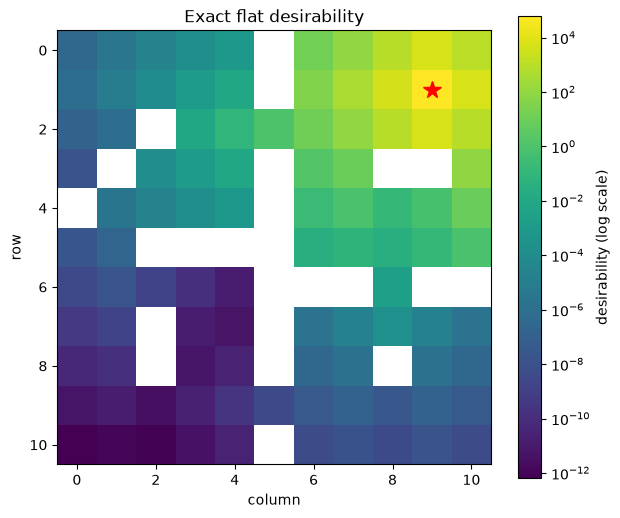

In [3]:
flat = environment.solve_flat(goal, parameters=flat_parameters)
flat_grid = desirability_grid(maze, flat.desirability)
positive = flat_grid[np.isfinite(flat_grid) & (flat_grid > 0.0)]

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(
    flat_grid,
    cmap="viridis",
    norm=LogNorm(vmin=positive.min(), vmax=positive.max()),
)
ax.plot(goal[1], goal[0], marker="*", color="red", markersize=13)
ax.set(title="Exact flat desirability", xlabel="column", ylabel="row")
fig.colorbar(image, ax=ax, label="desirability (log scale)")
plt.show()

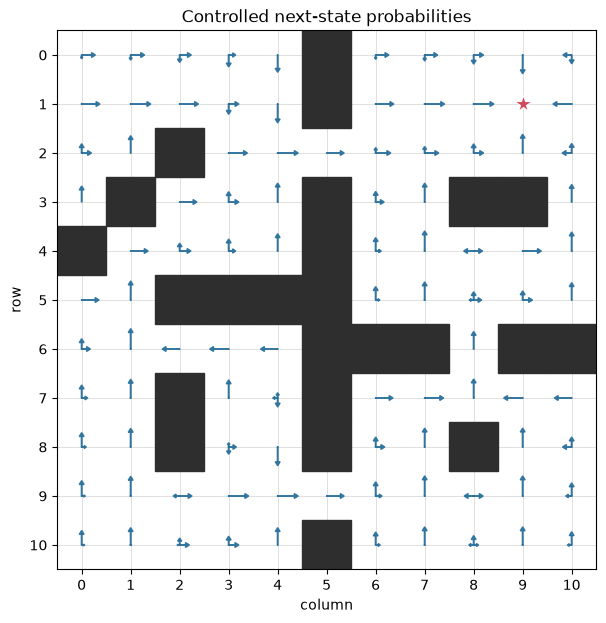

reached goal: True
physical steps: 19


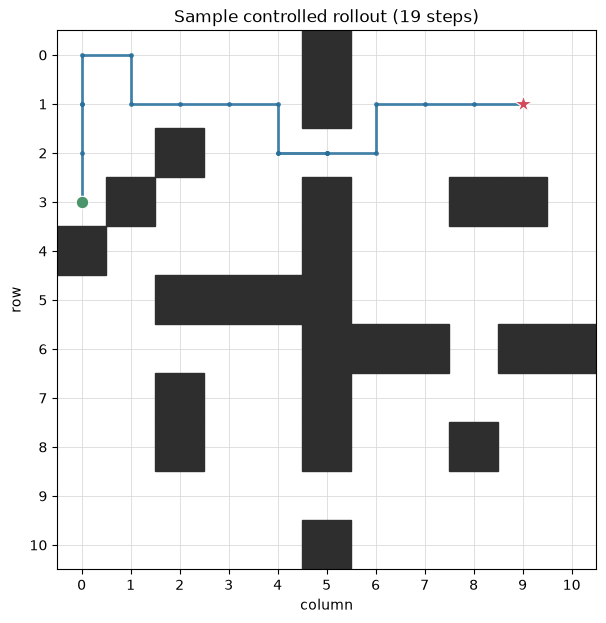

In [4]:
viz.plot_controlled_dynamics(maze, flat.controlled, goal=goal)
plt.show()

flat_start = (3, 0)
flat_rollout = flat.rollout(flat_start, seed=0)
print(f"reached goal: {flat_rollout[-1] == goal}")
print(f"physical steps: {len(flat_rollout) - 1}")
viz.plot_trajectory(maze, flat_rollout, goal=goal)
plt.show()

## Fixed-subgoal two-layer hierarchy

Point subgoals are represented internally as one-hot profile columns. The same hierarchy implementation is used later for distributed profiles.

In [5]:
subgoal_labels = ("A", "B", "C", "D", "E", "F")
subgoals = (
    (0, 0),
    (9, 2),
    (2, 3),
    (3, 7),
    (9, 7),
    (7, 9),
)
hierarchical_start = (3, 2)
point_basis = SubgoalBasis.from_locations(
    maze, subgoals, labels=subgoal_labels
)
hierarchy = environment.hierarchy(
    point_basis,
    parameters=hard_parameters,
    include_goal_component_while_active=False,
)
task = hierarchy.for_goal(goal)

### Task-independent passive subgoal graph

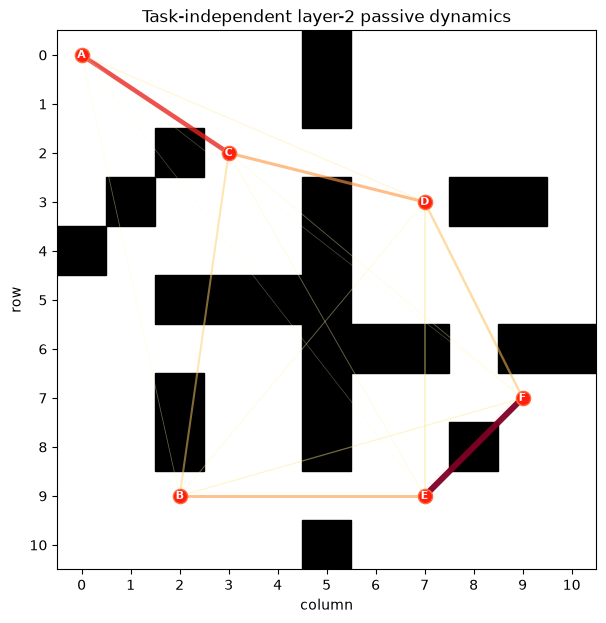

[[0.8481 0.0091 0.1169 0.0204 0.0028 0.0027]
 [0.0091 0.8376 0.0452 0.0129 0.0713 0.0239]
 [0.1169 0.0452 0.741  0.0741 0.0121 0.0106]
 [0.0204 0.0129 0.0741 0.8069 0.0313 0.0544]
 [0.0028 0.0713 0.0121 0.0313 0.7218 0.1608]
 [0.0027 0.0239 0.0106 0.0544 0.1608 0.7477]]


In [6]:
subgoal_passive = hierarchy.passive_dynamics
fig, ax = plt.subplots(figsize=(7, 7))
viz.plot_subgoal_passive_dynamics(
    maze,
    subgoals,
    subgoal_passive,
    labels=subgoal_labels,
    ax=ax,
)
plt.show()
print(np.round(subgoal_passive, 4))

### Goal-conditioned matrices and task composition

target order: ('A', 'B', 'C', 'D', 'E', 'F', 'goal')
lower passive: (103, 96)
boundary basis Q_b: (7, 7)
interior basis Z_i: (96, 7)
upper passive: (7, 6)


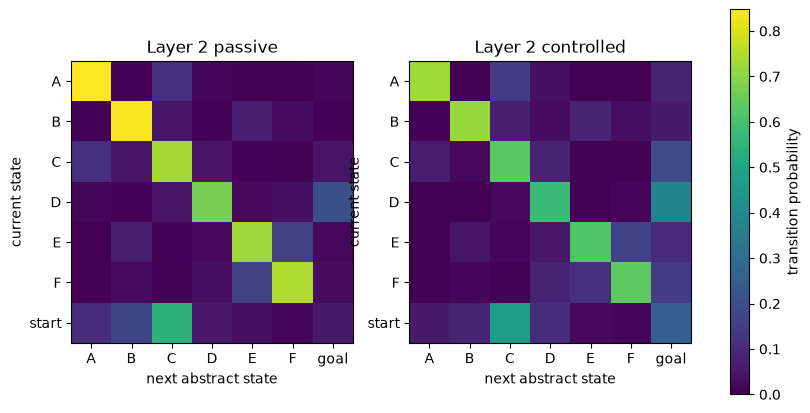

In [7]:
print("target order:", subgoal_labels + ("goal",))
print("lower passive:", task.lower_dynamics.passive.shape)
print("boundary basis Q_b:", task.task_basis.boundary_desirability.shape)
print("interior basis Z_i:", task.task_basis.interior_desirability.shape)
print("upper passive:", task.upper_dynamics.passive.shape)

initial_plan = task.plan(hierarchical_start)
abstract_labels = subgoal_labels + ("goal",)
source_labels = subgoal_labels + ("start",)
passive_matrix = np.vstack(
    (task.upper_dynamics.passive.T, initial_plan.passive_abstract)
)
controlled_matrix = np.vstack(
    (task.upper_controlled.T, initial_plan.controlled_abstract)
)
transition_matrices = (passive_matrix, controlled_matrix)
expected_shape = (len(source_labels), len(abstract_labels))
assert all(matrix.shape == expected_shape for matrix in transition_matrices)
assert all(
    np.allclose(matrix.sum(axis=1), 1.0)
    for matrix in transition_matrices
)
matrix_maximum = max(matrix.max() for matrix in transition_matrices)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, matrix, title in (
    (axes[0], passive_matrix, "Layer 2 passive"),
    (axes[1], controlled_matrix, "Layer 2 controlled"),
):
    image = ax.imshow(matrix, cmap="viridis", vmin=0.0, vmax=matrix_maximum)
    ax.set_xticks(np.arange(len(abstract_labels)), abstract_labels)
    ax.set_yticks(np.arange(len(source_labels)), source_labels)
    ax.set(xlabel="next abstract state", ylabel="current state", title=title)
fig.colorbar(image, ax=axes, label="transition probability")
plt.show()

 target   passive  controlled  reward    weight
    A      0.107       0.060     -0.738     0.000
    B      0.178       0.080     -1.577     0.000
    C      0.548       0.470     -1.252     0.000
    D      0.057       0.107      0.798     0.006
    E      0.033       0.019     -0.221     0.000
    F      0.015       0.010     -0.070     0.000
 goal      0.062       0.254      1.100     0.000


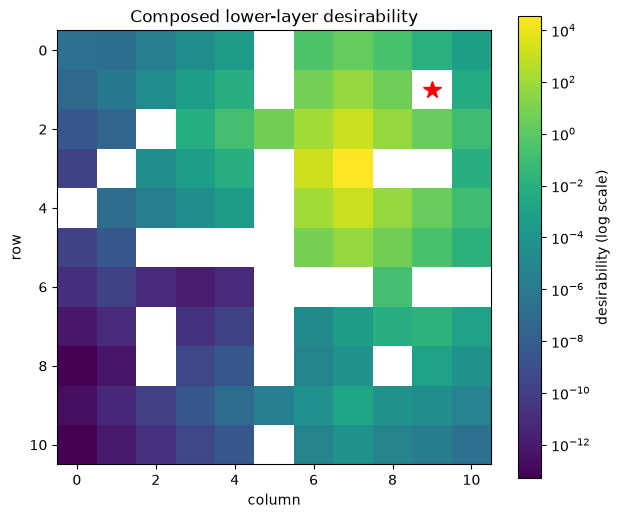

In [8]:
print(" target   passive  controlled  reward    weight")
for label, passive, controlled, reward, weight in zip(
    abstract_labels,
    initial_plan.passive_abstract,
    initial_plan.controlled_abstract,
    initial_plan.inpainted_rewards,
    initial_plan.weights,
):
    print(
        f" {label:>4}    {passive:7.3f}     {controlled:7.3f}"
        f"    {reward:7.3f}   {weight:7.3f}"
    )

composed_grid = desirability_grid(maze, initial_plan.physical_desirability)
positive = composed_grid[np.isfinite(composed_grid) & (composed_grid > 0.0)]
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(
    composed_grid,
    cmap="viridis",
    norm=LogNorm(vmin=positive.min(), vmax=positive.max()),
)
ax.plot(goal[1], goal[0], marker="*", color="red", markersize=13)
ax.set(title="Composed lower-layer desirability", xlabel="column", ylabel="row")
fig.colorbar(image, ax=ax, label="desirability (log scale)")
plt.show()

### Exact and online hierarchical rollouts

status: reached_goal
physical steps: 92
zero-time accesses: (SubgoalAccess(index=3, coordinate=(3, 7), physical_steps=9, terminated=False), SubgoalAccess(index=2, coordinate=(2, 3), physical_steps=14, terminated=False), SubgoalAccess(index=3, coordinate=(3, 7), physical_steps=20, terminated=False), SubgoalAccess(index=5, coordinate=(7, 9), physical_steps=26, terminated=False), SubgoalAccess(index=3, coordinate=(3, 7), physical_steps=33, terminated=False), SubgoalAccess(index=2, coordinate=(2, 3), physical_steps=38, terminated=False), SubgoalAccess(index=3, coordinate=(3, 7), physical_steps=43, terminated=False), SubgoalAccess(index=2, coordinate=(2, 3), physical_steps=48, terminated=False), SubgoalAccess(index=3, coordinate=(3, 7), physical_steps=53, terminated=False), SubgoalAccess(index=2, coordinate=(2, 3), physical_steps=61, terminated=False), SubgoalAccess(index=3, coordinate=(3, 7), physical_steps=66, terminated=False), SubgoalAccess(index=2, coordinate=(2, 3), physical_steps=72,

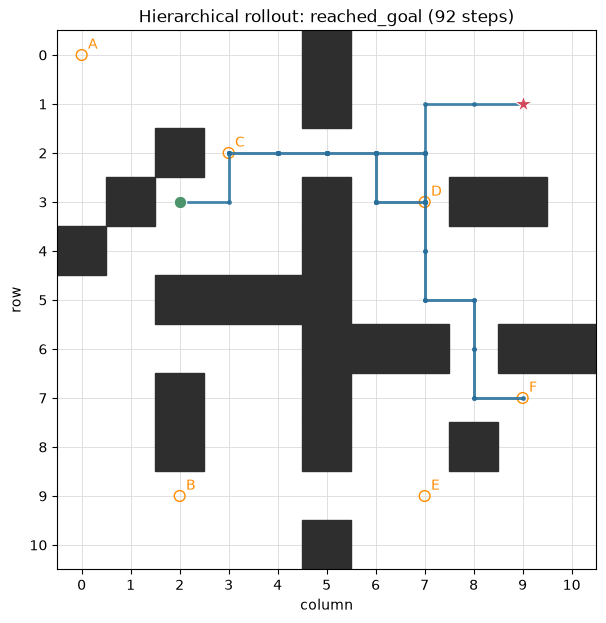

In [9]:
hierarchical_rollout = task.rollout(hierarchical_start, seed=0)
print("status:", hierarchical_rollout.status)
print("physical steps:", hierarchical_rollout.physical_steps)
print("zero-time accesses:", hierarchical_rollout.accesses)

ax = viz.plot_trajectory(maze, hierarchical_rollout.trajectory, goal=goal)
for label, (row, column) in zip(subgoal_labels, subgoals):
    ax.scatter(column, row, s=60, facecolors="none", edgecolors="darkorange")
    ax.text(column + 0.13, row - 0.13, label, color="darkorange")
ax.set_title(
    f"Hierarchical rollout: {hierarchical_rollout.status} "
    f"({hierarchical_rollout.physical_steps} steps)"
)
plt.show()

In [ ]:
from IPython.display import HTML

rollout_animation = viz.animate_hierarchical_rollout(
    task,
    hierarchical_start,
    seed=0,
    max_steps=100,
    interval=450,
    subgoal_labels=subgoal_labels,
)
HTML(rollout_animation.to_jshtml())

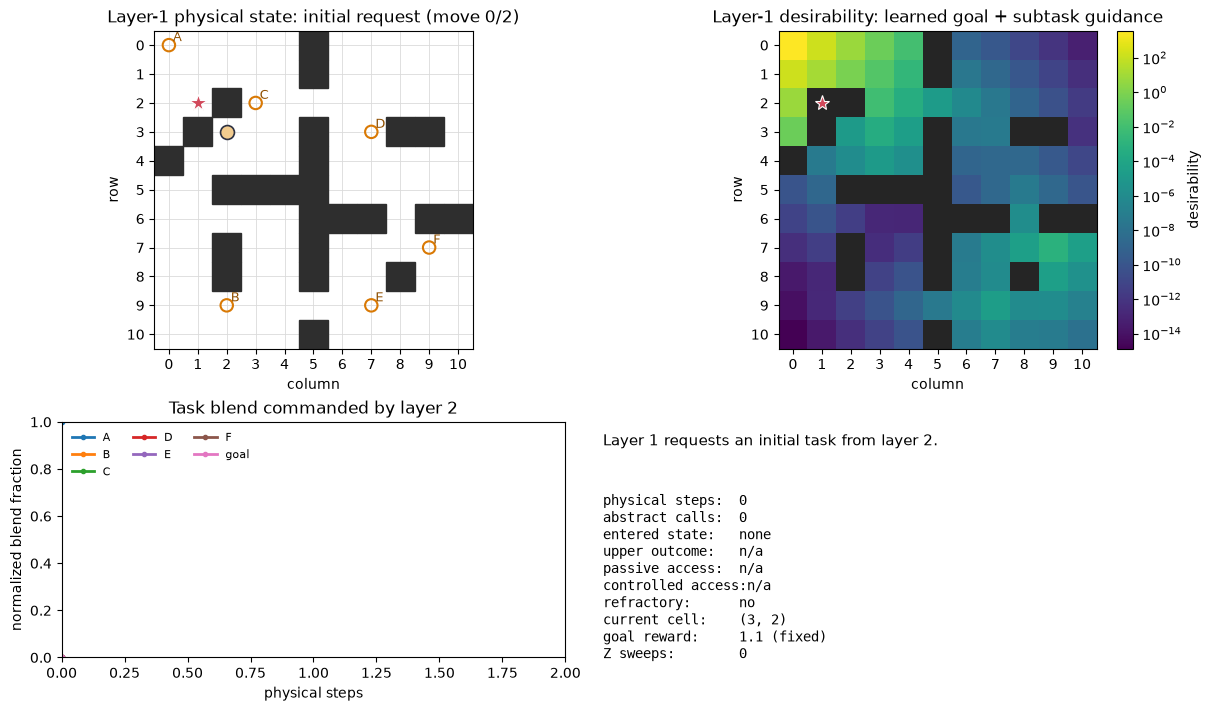

In [ ]:
online_animation = viz.animate_hierarchical_rollout(
    task,
    hierarchical_start,
    goal_learning="online",
    z_sweeps_per_step=1,
    max_steps=100,
    seed=28,
    interval=450,
    subgoal_labels=subgoal_labels,
)
HTML(online_animation.to_jshtml())

In [ ]:
learned_goal = None
online_episodes = []
for episode_seed in range(5):
    episode = task.rollout(
        hierarchical_start,
        goal_learning="online",
        initial_goal_desirability=learned_goal,
        z_sweeps_per_step=1,
        max_steps=100,
        seed=episode_seed,
    )
    online_episodes.append(episode)
    learned_goal = episode.final_goal_desirability

for index, episode in enumerate(online_episodes, start=1):
    print(
        f"episode {index}: {episode.status}, "
        f"{episode.physical_steps} physical steps, "
        f"{episode.z_iterations} Z sweeps"
    )

episode 1: reached_goal, 29 physical steps, 28 Z sweeps
episode 2: reached_goal, 17 physical steps, 16 Z sweeps
episode 3: reached_goal, 6 physical steps, 5 Z sweeps
episode 4: reached_goal, 7 physical steps, 6 Z sweeps
episode 5: reached_goal, 6 physical steps, 5 Z sweeps


### Interactive fixed-subgoal composition

Drag the agent and goal markers to inspect the fixed-basis task blend.

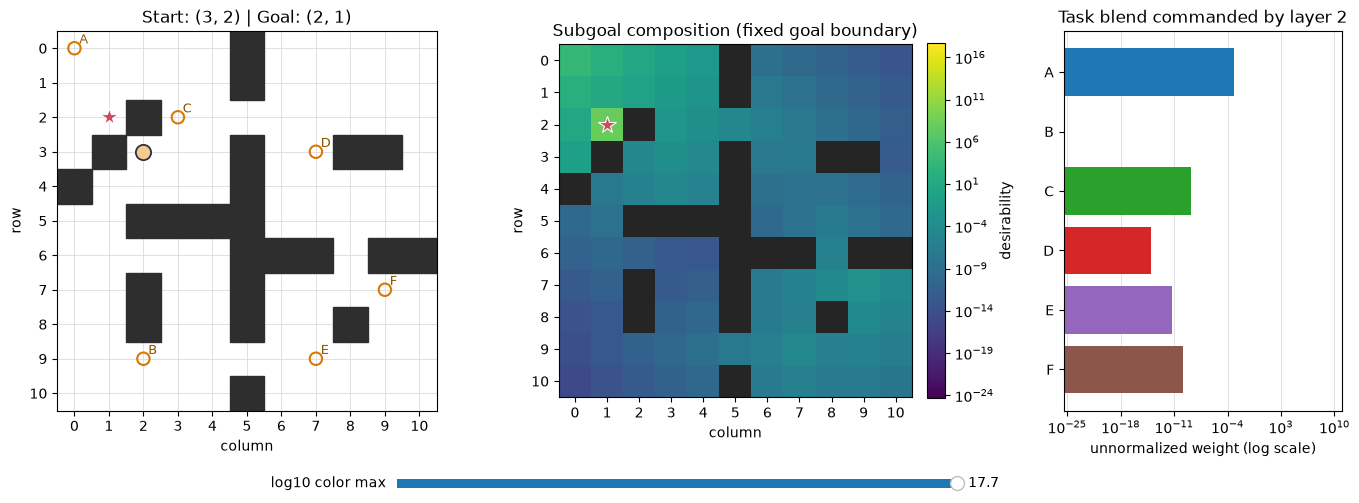

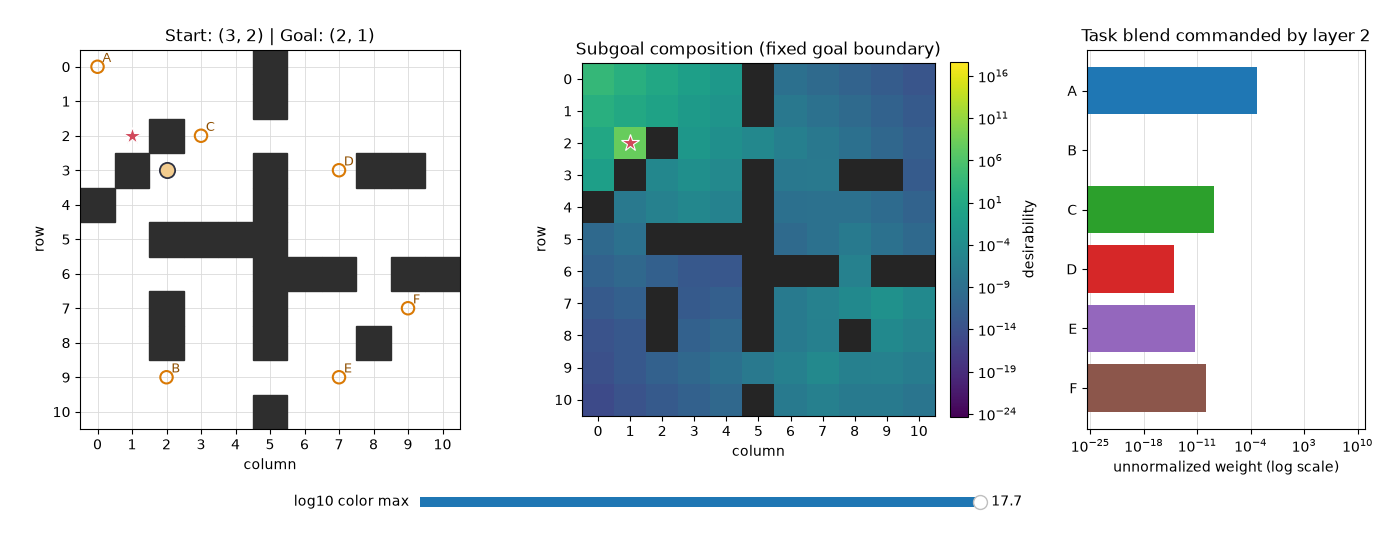

In [ ]:
%matplotlib widget
interactive_figure = viz.plot_interactive_subgoal_desirability(
    task,
    hierarchical_start,
    subgoal_labels=subgoal_labels,
)
interactive_figure

## NMF-discovered core-gated soft subgoals

Every requested rank is fitted once. The rank-eight result below is reused directly after plotting the rank diagnostics.

normalized KL error: 1.370; 110 iterations; converged=True


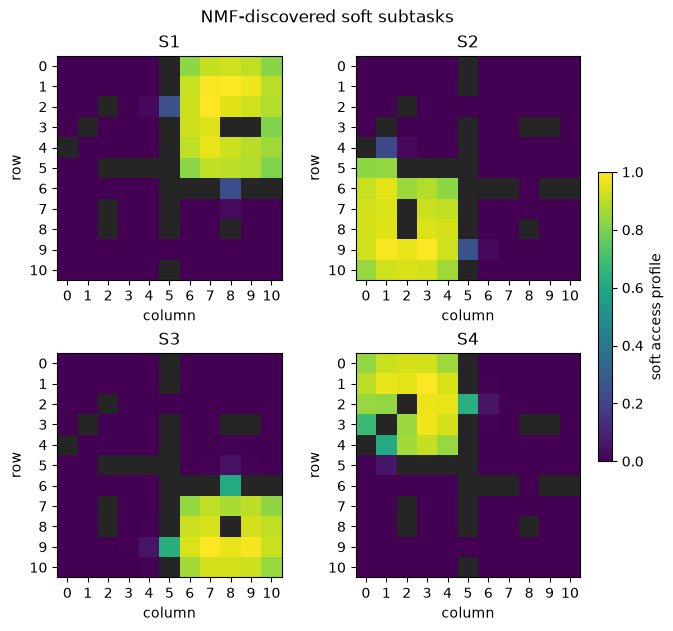

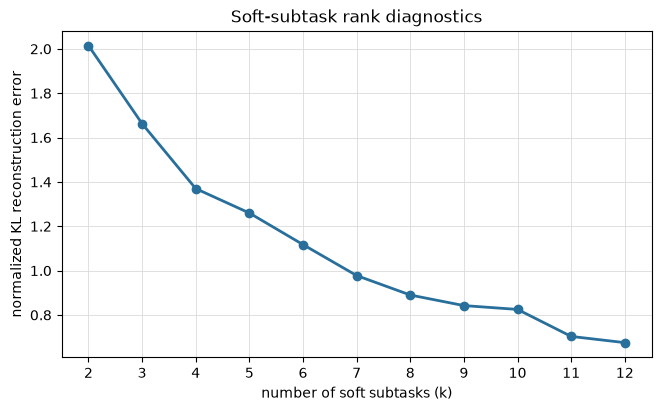

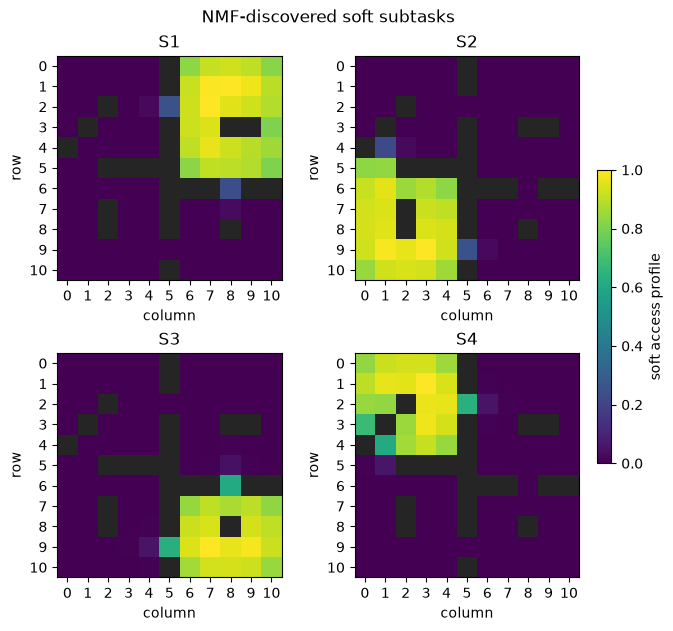

In [ ]:
%matplotlib inline
soft_study = discover_soft_subgoals(
    environment,
    ranks=tuple(range(2, 13)),
    parameters=NMFDiscoveryParameters(),
)
viz.plot_soft_subtask_rank_diagnostics(soft_study.diagnostics)
soft_discovery = soft_study.result(4)
print(
    f"normalized KL error: {soft_discovery.reconstruction_error:.3f}; "
    f"{soft_discovery.n_iter} iterations; "
    f"converged={soft_discovery.converged}"
)
viz.plot_soft_subtasks(soft_discovery)

In [ ]:
soft_basis = SubgoalBasis.from_profiles(
    maze,
    soft_discovery.profiles,
    core_threshold=0.8,
    core_exponent=1.0,
)
soft_template = environment.hierarchy(
    soft_basis,
    parameters=soft_hierarchy_parameters(k=8, upper_control_cost=0.18),
    include_goal_component_while_active=False,
)

### Interactive soft rollout

Drag the green start circle and red goal star to stage new free cells, then press **Recompute rollout**. Recompute builds only the cached goal-conditioned task and samples one trajectory; it does not rerun NMF or reapply the core gate.

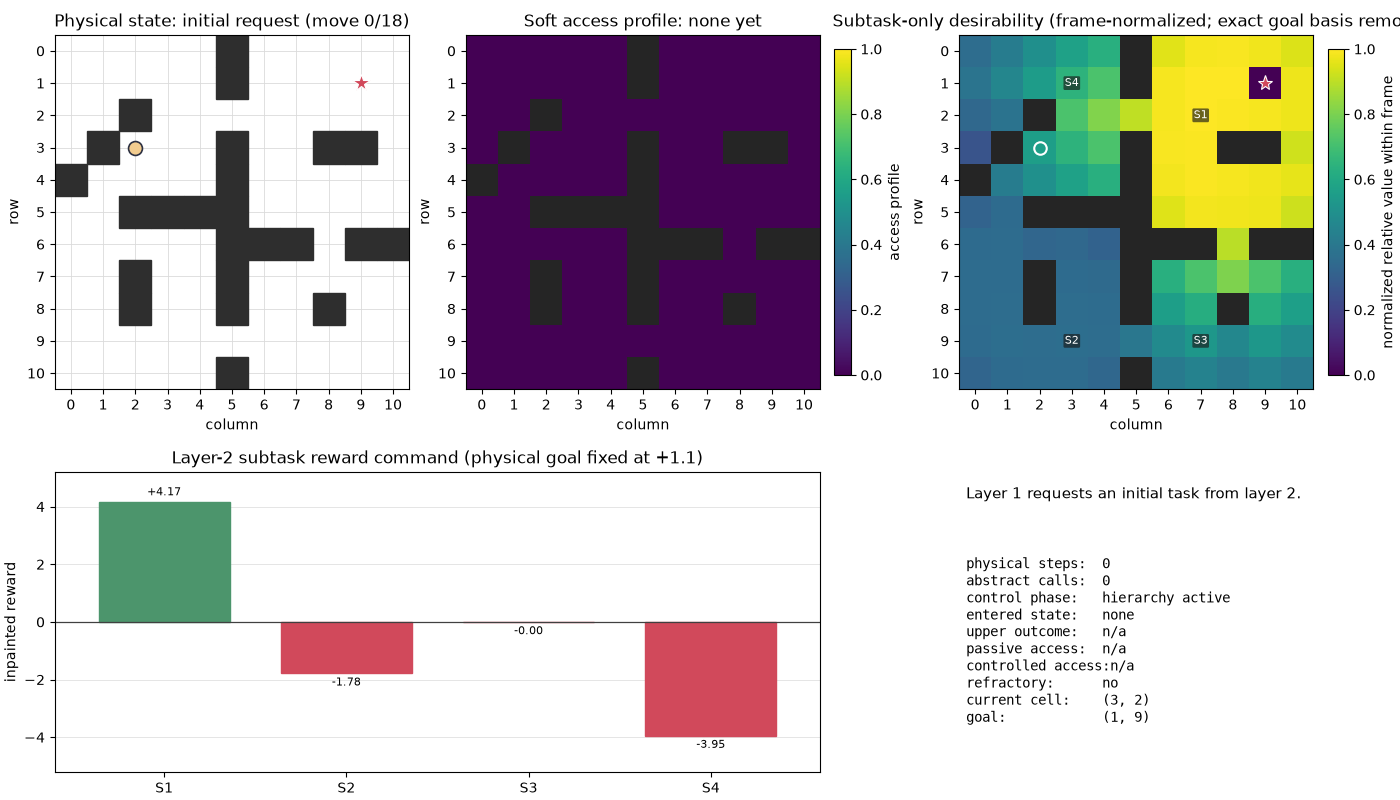

In [ ]:
%matplotlib widget
from IPython.display import display

soft_player = viz.plot_interactive_soft_hierarchical_rollout(
    soft_template,
    hierarchical_start,
    goal,
    max_steps=100,
    max_abstract_accesses=100,
    seed=0,
)
display(soft_player.controls)
plt.show()